<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [2]:
#Importation du fichier population.csv
population = pd.read_csv('https://docs.google.com/spreadsheets/d/1Wsk7Fvj9pH2jUNPXPVGxDslfDOzS-iA9HSaHLMqg0HA/export?format=csv&gid=1259631766')
print(population.head())

#Importation du fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv('https://docs.google.com/spreadsheets/d/1vlrELGSe9odhnLz3d2m3d1t9G5EECD0biwqo-vooiqY/export?format=csv&gid=707172356')
print(dispo_alimentaire.head())

#Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv('https://docs.google.com/spreadsheets/d/1Qika4uHje7Z0uRHp4oq_LyJeQcDmcRYnwztBs6fdjtU/export?format=csv&gid=107121591')
print(aide_alimentaire.head())

#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv('https://docs.google.com/spreadsheets/d/1I-OyZoV7NfJqBZozp4mYXQMc1j7czFN19znPbCgjekU/export?format=csv&gid=14372013')
print(sous_nutrition.head())

          Zone  Année     Valeur
0  Afghanistan   2013  32269.589
1  Afghanistan   2014  33370.794
2  Afghanistan   2015  34413.603
3  Afghanistan   2016  35383.032
4  Afghanistan   2017  36296.113
          Zone                Produit   Origine  Aliments pour animaux  \
0  Afghanistan       Abats Comestible   animale                    NaN   
1  Afghanistan        Agrumes, Autres  vegetale                    NaN   
2  Afghanistan  Aliments pour enfants  vegetale                    NaN   
3  Afghanistan                 Ananas  vegetale                    NaN   
4  Afghanistan                Bananes  vegetale                    NaN   

   Autres Utilisations  Disponibilité alimentaire (Kcal/personne/jour)  \
0                  NaN                                             5.0   
1                  NaN                                             1.0   
2                  NaN                                             1.0   
3                  NaN                                       

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [3]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [4]:
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s)".format(len(population.columns)))


#La nature des données dans chacune des colonnes
print(population.dtypes)



#Le nombre de valeurs présentes dans chacune des colonnes
print(population.count())


Le tableau comporte 3 colonne(s)
Zone       object
Année       int64
Valeur    float64
dtype: object
Zone      1416
Année     1416
Valeur    1416
dtype: int64


In [5]:
#Affichage les 5 premières lignes de la table
population.head(5)



,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [6]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
population["Valeur"] = population["Valeur"] * 1000


In [7]:
#changement du nom de la colonne Valeur par Population
population = population.rename(columns={"Valeur": "Population"})

In [8]:
#Affichage les 5 premières lignes de la table pour voir les modifications
population.head(5)

,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [9]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(dispo_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(dispo_alimentaire.shape[1]))

Le tableau comporte 15605 observation(s) ou article(s)
Le tableau comporte 18 colonne(s)


In [78]:
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s)".format(len(dispo_alimentaire.columns)))


Le tableau comporte 18 colonne(s)


In [11]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [12]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire = dispo_alimentaire.fillna(0)
#Affichage les 5 premières lignes de la table pour voir les modifications
dispo_alimentaire.head(5)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53.0,0.0,0.0,53.0,0.0,53.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82.0,0.0,82.0,82.0,0.0,0.0,0.0,0.0,0.0


In [13]:

#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
# Colonnes exprimées en milliers de tonnes (selon le lexique FAO)
colonnes_milliers_tonnes = [
    "Production",
    "Importations - Quantité",
    "Exportations - Quantité",
    "Variation de stock",
    "Disponibilité intérieure",
    "Nourriture",
    "Aliments pour animaux",
    "Autres Utilisations",
    "Semences",
    "Traitement",
    "Pertes"
]

# Conversion : milliers de tonnes -> kilogrammes
# 1 millier de tonnes = 1 000 000 kg
dispo_alimentaire[colonnes_milliers_tonnes] = (
    dispo_alimentaire[colonnes_milliers_tonnes] * 1000000
)



In [14]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head(5)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [15]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(aide_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(aide_alimentaire.shape[1]))

Le tableau comporte 1475 observation(s) ou article(s)
Le tableau comporte 4 colonne(s)


In [16]:
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s)".format(len(aide_alimentaire.columns)))


Le tableau comporte 4 colonne(s)


In [17]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head(5)

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [18]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire = aide_alimentaire.rename(columns={"Pays bénéficiaire": "Zone"})
#Affichage les 5 premières lignes de la table pour voir les modifications
aide_alimentaire.head(5)


,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [19]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire["Valeur"] = aide_alimentaire["Valeur"] * 1000


In [20]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head(5)

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.4 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [21]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(sous_nutrition.shape[0]))
print("Le tableau comporte {} colonne(s)".format(sous_nutrition.shape[1]))

Le tableau comporte 1218 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [22]:
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s)".format(len(sous_nutrition.columns)))


Le tableau comporte 3 colonne(s)


In [23]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head(5)

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [24]:
#Conversion de la colonne sous nutrition en numérique
# Les valeurs "<0.1" signifient moins de 0,1 %
# On les remplace par 0 pour pouvoir travailler avec des nombres
sous_nutrition["Valeur"] = sous_nutrition["Valeur"].replace("<0.1", "0")
sous_nutrition["Valeur"] = pd.to_numeric(sous_nutrition["Valeur"])

In [25]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition = sous_nutrition.rename(columns={"Valeur": "Sous_nutrition"})


In [26]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition["Sous_nutrition"] = sous_nutrition["Sous_nutrition"] * 1000000

In [27]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head(5)

,Zone,Année,Sous_nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [28]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017


In [29]:
# Filtrage des données de sous-nutrition correspondant à 2017 (période 2016-2018 selon le lexique des données)
sous_nutrition_2017 = sous_nutrition[sous_nutrition["Année"] == "2016-2018"]


In [30]:
# Filtrage de la population pour l'année 2017
population_2017 = population[population["Année"] == 2017]


In [31]:
# Jointure des deux tables sur les colonnes "Zone" et "Année"
table_2017 = pd.merge(
    sous_nutrition_2017,
    population_2017,
    on="Zone",
    how="inner"
)
# La jointure est faite uniquement sur la colonne Zone car
# la sous-nutrition correspond à une période (2016-2018)
# alors que la population est une valeur pour l'année 2017

In [32]:
#Affichage du dataset

table_2017.head()

,Zone,Année_x,Sous_nutrition,Année_y,Population
0,Afghanistan,2016-2018,10500000.0,2017,36296113.0
1,Afrique du Sud,2016-2018,3100000.0,2017,57009756.0
2,Albanie,2016-2018,100000.0,2017,2884169.0
3,Algérie,2016-2018,1300000.0,2017,41389189.0
4,Allemagne,2016-2018,NaN,2017,82658409.0


In [33]:
# Nettoyage du dataset final en supprimant les colonnes inutiles et en renommant certaines colonnes
table_2017 = table_2017.drop(columns=["Année_x"])
table_2017 = table_2017.rename(columns={"Année_y": "Période"})
table_2017.head()

,Zone,Sous_nutrition,Période,Population
0,Afghanistan,10500000.0,2017,36296113.0
1,Afrique du Sud,3100000.0,2017,57009756.0
2,Albanie,100000.0,2017,2884169.0
3,Algérie,1300000.0,2017,41389189.0
4,Allemagne,NaN,2017,82658409.0


In [34]:
# Remplacement des valeurs manquantes de sous-nutrition par 0
# Cela permet d'inclure tous les pays dans le calcul global
table_2017["Sous_nutrition"] = table_2017["Sous_nutrition"].fillna(0)


In [35]:
# Calcul du nombre total de personnes en état de sous-nutrition
total_sous_nutrition = table_2017["Sous_nutrition"].sum()

# Affichage du résultat
print("le total de personnes en état de sous-nutrition est de :", total_sous_nutrition, "personnes")



le total de personnes en état de sous-nutrition est de : 535700000.0 personnes


In [36]:
# Calcul de la population totale en 2017
population_totale_2017 = table_2017["Population"].sum()

# Calcul de la proportion de sous-nutrition (%)
proportion_sous_nutrition_2017 = (
    total_sous_nutrition / population_totale_2017
) * 100

# Affichage du résultat
print(
    "La proportion de personnes en état de sous-nutrition en 2017 est de :",
    round(proportion_sous_nutrition_2017, 2),
    "%"
)

La proportion de personnes en état de sous-nutrition en 2017 est de : 7.1 %


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [37]:
#Combien mange en moyenne un être humain ? Source => Selon la FAO et l’OMS :
# Un être humain consomme en moyenne environ 2 500 kcal par jour,
# soit près de 800 kg de nourriture par an.

In [38]:
# Filtrage de la population pour l'année 2017
population_2017 = population[population["Année"] == 2017]


In [39]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population

dispo_pop = pd.merge(
    dispo_alimentaire,
    population_2017,
    on="Zone",
    how="inner"
)


In [40]:
#Affichage du nouveau dataframe
dispo_pop.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année,Population
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0,2017,36296113.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,2017,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,2017,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017,36296113.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,2017,36296113.0


In [41]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
dispo_pop["dispo_kcal"] = dispo_pop["Disponibilité alimentaire (Kcal/personne/jour)"] * dispo_pop["Population"]
dispo_pop.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année,Population,dispo_kcal
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,...,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0,2017,36296113.0,181480565.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,...,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,2017,36296113.0,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,...,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,2017,36296113.0,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017,36296113.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,...,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,2017,36296113.0,145184452.0


In [42]:
#Calcul du nombre d'humains pouvant être nourris
besoin_kcal_jour = 2500

kcal_totales = dispo_pop["dispo_kcal"].sum()
humains_nourrissables = kcal_totales / besoin_kcal_jour

print("Nombre théorique de personnes pouvant être nourries :", humains_nourrissables,'personnes')


Nombre théorique de personnes pouvant être nourries : 8367593850.9324 personnes


# Interprétation :
Ce résultat est théorique : il suppose une répartition parfaite des ressources et ne tient pas compte des pertes, du gaspillage ou d'autres usages non alimentaires
=> Le calcul montre qu’en théorie, la disponibilité alimentaire mondiale permettrait de nourrir l’ensemble de la population mondiale, ce qui souligne que la sous-nutrition est avant tout liée à d'autres problèmes hors de la disponibilité/production.

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [43]:
#Transfert des données avec les végétaux dans un nouveau dataframe

dispo_vegetaux = dispo_pop[dispo_pop["Origine"] == "vegetale"]
dispo_vegetaux.head()


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année,Population,dispo_kcal
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,...,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,2017,36296113.0,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,...,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,2017,36296113.0,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017,36296113.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,...,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,2017,36296113.0,145184452.0
6,Afghanistan,Bière,vegetale,0.0,0.0,0.0,0.09,0.00,0.00,3000000.0,...,3000000.0,3000000.0,0.0,0.0,0.0,0.0,0.0,2017,36296113.0,0.0


In [44]:
#Calcul du nombre de kcal disponible pour les végétaux
kcal_vegetaux = dispo_vegetaux["dispo_kcal"].sum()

print(" nombre de kcal disponibles pour les végétaux :", kcal_vegetaux)


 nombre de kcal disponibles pour les végétaux : 17260764211501.0


In [45]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
besoin_kcal_jour = 2500

humains_nourris_vegetaux = kcal_vegetaux / besoin_kcal_jour

print(
    "Nombre théorique de personnes pouvant être nourries avec les végétaux :",
    humains_nourris_vegetaux,"personnes")

Nombre théorique de personnes pouvant être nourries avec les végétaux : 6904305684.6004 personnes


# Interprétation :

L’analyse montre qu’en théorie, les produits d’origine **végétale** permettraient à eux seuls de nourrir environ **6,9 milliards de personnes** soit **92% de la population mondiale**. Ce résultat souligne leur **rôle central** dans l’alimentation mondiale.

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [46]:
#Calcul de la disponibilité totale
dispo_totale = dispo_alimentaire["Disponibilité intérieure"].sum()

print("Disponibilité intérieure totale :", dispo_totale, "kg")
#La conversion était déjà faite dans la partie 2.2

Disponibilité intérieure totale : 9848994000000.0 kg


In [81]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures, 
colonnes_usages = [
    "Nourriture",
    "Aliments pour animaux",
    "Pertes",
    "Autres Utilisations",
    "Semences",
    "Traitement",
]

for colonne in colonnes_usages:
    somme_colonne = dispo_alimentaire[colonne].sum()
    pourcentage = (somme_colonne / dispo_totale) * 100

    print(
        colonne,
        ":",
        somme_colonne,
        "kg",
        "|",
        round(pourcentage, 1),
        "%"
    )

Nourriture : 4876258000000.0 kg | 49.5 %
Aliments pour animaux : 1304245000000.0 kg | 13.2 %
Pertes : 453698000000.0 kg | 4.6 %
Autres Utilisations : 865023000000.0 kg | 8.8 %
Semences : 154681000000.0 kg | 1.6 %
Traitement : 2204687000000.0 kg | 22.4 %


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [48]:
#Création d'une liste avec toutes les variables
liste_cereales = [
    "Blé",
    "Riz (Eq Blanchi)",
    "Orge",
    "Maïs",
    "Seigle",
    "Avoine",
    "Millet",
    "Sorgho",
    "Céréales, Autres"
]




In [49]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
dispo_cereales = dispo_alimentaire [dispo_alimentaire["Produit"].isin(liste_cereales)]
dispo_cereales.head()


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
7,Afghanistan,Blé,vegetale,0.0,0.0,1369.0,160.23,4.69,36.91,5.992000e+09,0.0,1.173000e+09,4.895000e+09,775000000.0,5.169000e+09,322000000.0,0.0,-350000000.0
12,Afghanistan,"Céréales, Autres",vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0
32,Afghanistan,Maïs,vegetale,200000000.0,0.0,21.0,2.50,0.30,0.56,3.130000e+08,0.0,1.000000e+06,7.600000e+07,31000000.0,3.120000e+08,5000000.0,0.0,0.0
34,Afghanistan,Millet,vegetale,0.0,0.0,3.0,0.40,0.02,0.08,1.300000e+07,0.0,0.000000e+00,1.200000e+07,1000000.0,1.300000e+07,0.0,0.0,0.0
40,Afghanistan,Orge,vegetale,360000000.0,0.0,26.0,2.92,0.24,0.79,5.240000e+08,0.0,1.000000e+07,8.900000e+07,52000000.0,5.140000e+08,22000000.0,0.0,0.0


In [50]:
# Calcul de la quantité totale de céréales disponibles
dispo_interieure_totale = dispo_cereales["Disponibilité intérieure"].sum()
print("Disponibilité intérieure totale pour les céréales :", dispo_interieure_totale, "kg")



Disponibilité intérieure totale pour les céréales : 2406999000000.0 kg


In [51]:
# Calcul de la quantité de céréales utilisée pour l'alimentation humaine
nourriture_totale = dispo_cereales["Nourriture"].sum()
print("Quantité totale de céréales utilisée pour l'alimentation humaine :", nourriture_totale, "kg")


Quantité totale de céréales utilisée pour l'alimentation humaine : 1029010000000.0 kg


In [52]:
#Affichage de la proportion d'alimentation humaine 
proportion_nourriture = (nourriture_totale / dispo_interieure_totale)
print("Proportion de céréales utilisées pour l'alimentation humaine :", 
    round(proportion_nourriture * 100, 2), "%")


Proportion de céréales utilisées pour l'alimentation humaine : 42.75 %


In [53]:
# Calcul de la quantité de céréales utilisée pour l'alimentation animale
aliments_animaux_totale = dispo_cereales["Aliments pour animaux"].sum()
print("Quantité totale de céréales utilisée pour l'alimentation animale :", aliments_animaux_totale, "kg")

Quantité totale de céréales utilisée pour l'alimentation animale : 873535000000.0 kg


In [54]:
#Affichage de la proportion d'alimentation animale
proportion_animaux = aliments_animaux_totale / dispo_interieure_totale
print( "Proportion des céréales utilisées pour l'alimentation animale :",
    round(proportion_animaux * 100, 2),"%")


Proportion des céréales utilisées pour l'alimentation animale : 36.29 %


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [55]:
#Création de la colonne proportion par pays
table_2017["proportion_sous_nutrition (%)"] = (
    table_2017["Sous_nutrition"] / table_2017["Population"]* 100).round(2)

table_2017.head()

,Zone,Sous_nutrition,Période,Population,proportion_sous_nutrition (%)
0,Afghanistan,10500000.0,2017,36296113.0,28.93
1,Afrique du Sud,3100000.0,2017,57009756.0,5.44
2,Albanie,100000.0,2017,2884169.0,3.47
3,Algérie,1300000.0,2017,41389189.0,3.14
4,Allemagne,0.0,2017,82658409.0,0.00


In [56]:
#affichage après trie des 10 pires pays
table_2017.sort_values(by="proportion_sous_nutrition (%)", ascending=False).head(10)


,Zone,Sous_nutrition,Période,Population,proportion_sous_nutrition (%)
78,Haïti,5300000.0,2017,10982366.0,48.26
157,République populaire démocratique de Corée,12000000.0,2017,25429825.0,47.19
108,Madagascar,10500000.0,2017,25570512.0,41.06
103,Libéria,1800000.0,2017,4702226.0,38.28
100,Lesotho,800000.0,2017,2091534.0,38.25
183,Tchad,5700000.0,2017,15016753.0,37.96
161,Rwanda,4200000.0,2017,11980961.0,35.06
121,Mozambique,9400000.0,2017,28649018.0,32.81
186,Timor-Leste,400000.0,2017,1243258.0,32.17
0,Afghanistan,10500000.0,2017,36296113.0,28.93


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [57]:
#calcul du total de l'aide alimentaire par pays
aide_par_pays = aide_alimentaire.groupby("Zone")["Valeur"].sum().reset_index()
aide_par_pays.head()


,Zone,Valeur
0,Afghanistan,185452000
1,Algérie,81114000
2,Angola,5014000
3,Bangladesh,348188000
4,Bhoutan,2666000


In [58]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire
aide_par_pays = aide_par_pays.rename(
    columns={"Valeur": "Valeur de l'aide alimentaire"},
)
aide_par_pays_sorted = (
    aide_par_pays
    .sort_values(by="Valeur de l'aide alimentaire", ascending=False)
    .reset_index(drop=True)
)
aide_par_pays_sorted.head(10)


,Zone,Valeur de l'aide alimentaire
0,République arabe syrienne,1858943000
1,Éthiopie,1381294000
2,Yémen,1206484000
3,Soudan du Sud,695248000
4,Soudan,669784000
5,Kenya,552836000
6,Bangladesh,348188000
7,Somalie,292678000
8,République démocratique du Congo,288502000
9,Niger,276344000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [59]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année 
aide_reduite = aide_alimentaire[["Zone", "Année", "Valeur"]]
aide_par_pays_annee = (
    aide_reduite
    .groupby(["Zone", "Année"])["Valeur"]
    .sum()
    .reset_index()
)
aide_par_pays_annee = aide_par_pays_annee.rename(
    columns={"Valeur": "Valeur de l'aide alimentaire"},
)
aide_par_pays_annee.head()

,Zone,Année,Valeur de l'aide alimentaire
0,Afghanistan,2013,128238000
1,Afghanistan,2014,57214000
2,Algérie,2013,35234000
3,Algérie,2014,18980000
4,Algérie,2015,17424000


In [60]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
aide_totale_par_pays = (
    aide_reduite
    .groupby("Zone")["Valeur"]
    .sum()
    .sort_values(ascending=False)
)
top_5_pays = aide_totale_par_pays.head(5)
liste_top_5 = top_5_pays.index.tolist()
liste_top_5




['République arabe syrienne', 'Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan']

In [61]:
#On filtre sur le dataframe avec notre liste
aide_top_5 = aide_par_pays_annee[
    aide_par_pays_annee["Zone"].isin(liste_top_5)
]

In [62]:
# Affichage des pays avec l'aide alimentaire par année
aide_top_5.head(20)

,Zone,Année,Valeur de l'aide alimentaire
157,République arabe syrienne,2013,563566000
158,République arabe syrienne,2014,651870000
159,République arabe syrienne,2015,524949000
160,République arabe syrienne,2016,118558000
189,Soudan,2013,330230000
190,Soudan,2014,321904000
191,Soudan,2015,17650000
192,Soudan du Sud,2013,196330000
193,Soudan du Sud,2014,450610000
194,Soudan du Sud,2015,48308000


In [63]:
#Affichage de l'évolution de l'aide alimentaire pour les 5 pays ayant le plus bénéficié de l'aide alimentaire
#Création d'un pivot table pour faciliter l'affichage avec matplotlib
evolution_pivot = aide_top_5.pivot(
    index="Année",
    columns="Zone",
    values="Valeur de l'aide alimentaire"
).sort_index()
evolution_pivot_millions = evolution_pivot / 1_000_000


<Figure size 640x480 with 0 Axes>

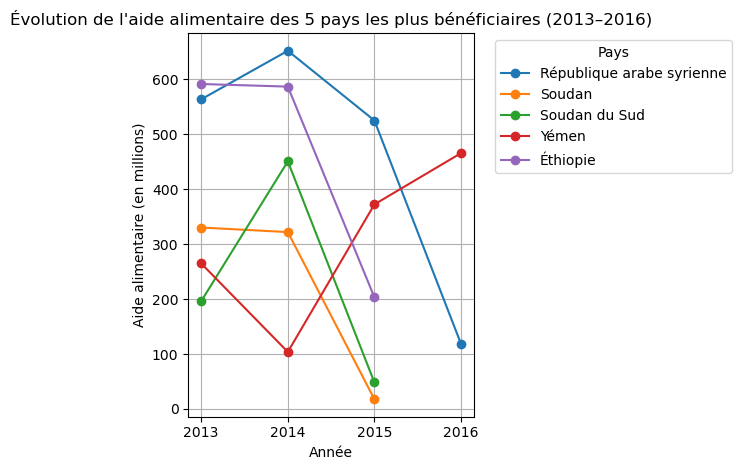

In [64]:
#Affichage avec matplotlib
import matplotlib.pyplot as plt

plt.figure()
evolution_pivot_millions.plot(marker="o")
plt.title("Évolution de l'aide alimentaire des 5 pays les plus bénéficiaires (2013–2016)")
plt.xlabel("Année")
plt.ylabel("Aide alimentaire (en millions)")
plt.grid(True)
plt.legend(title="Pays", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [65]:
#Calcul de la disponibilité en kcal par personne par jour par pays
dispo_par_pays = (
    dispo_alimentaire
    .groupby("Zone")["Disponibilité alimentaire (Kcal/personne/jour)"]
    .sum()
    .reset_index()
)
dispo_par_pays.head()

,Zone,Disponibilité alimentaire (Kcal/personne/jour)
0,Afghanistan,2087.0
1,Afrique du Sud,3020.0
2,Albanie,3188.0
3,Algérie,3293.0
4,Allemagne,3503.0


In [66]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne 
dispo_par_pays.sort_values(
    by="Disponibilité alimentaire (Kcal/personne/jour)",
    ascending=True
).head(10)

,Zone,Disponibilité alimentaire (Kcal/personne/jour)
128,République centrafricaine,1879.0
166,Zambie,1924.0
91,Madagascar,2056.0
0,Afghanistan,2087.0
65,Haïti,2089.0
133,République populaire démocratique de Corée,2093.0
151,Tchad,2109.0
167,Zimbabwe,2113.0
114,Ouganda,2126.0
172,Éthiopie,2129.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

In [67]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne 
dispo_par_pays.sort_values(
    by="Disponibilité alimentaire (Kcal/personne/jour)",
    ascending=False
).head(10)

,Zone,Disponibilité alimentaire (Kcal/personne/jour)
11,Autriche,3770.0
16,Belgique,3737.0
159,Turquie,3708.0
171,États-Unis d'Amérique,3682.0
74,Israël,3610.0
72,Irlande,3602.0
75,Italie,3578.0
89,Luxembourg,3540.0
168,Égypte,3518.0
4,Allemagne,3503.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [68]:
#création d'un dataframe avec uniquement la Thaïlande 
dispo_thailande = dispo_alimentaire[dispo_alimentaire["Zone"] == "Thaïlande"]
dispo_thailande

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
13759,Thaïlande,Abats Comestible,animale,0.0,0.0,3.0,1.11,0.09,0.56,74000000.0,5.000000e+06,33000000.0,75000000.0,0.0,4.500000e+07,0.0,0.0,0.0
13760,Thaïlande,"Agrumes, Autres",vegetale,0.0,0.0,0.0,0.09,0.00,0.00,8000000.0,6.000000e+06,2000000.0,6000000.0,0.0,1.200000e+07,0.0,2000000.0,0.0
13761,Thaïlande,"Alcool, non Comestible",vegetale,0.0,358000000.0,0.0,0.00,0.00,0.00,358000000.0,1.100000e+08,21000000.0,0.0,0.0,4.470000e+08,0.0,0.0,0.0
13762,Thaïlande,Aliments pour enfants,vegetale,0.0,0.0,2.0,0.18,0.01,0.08,12000000.0,7.000000e+06,19000000.0,12000000.0,0.0,0.000000e+00,0.0,0.0,0.0
13763,Thaïlande,Ananas,vegetale,0.0,0.0,10.0,10.02,0.04,0.08,782000000.0,1.449000e+09,9000000.0,671000000.0,110000000.0,2.209000e+09,0.0,0.0,13000000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13849,Thaïlande,Viande de Suides,animale,0.0,0.0,124.0,13.00,11.83,3.92,871000000.0,2.200000e+07,1000000.0,871000000.0,0.0,8.910000e+08,0.0,0.0,0.0
13850,Thaïlande,Viande de Volailles,animale,0.0,0.0,52.0,13.69,3.62,4.49,945000000.0,5.360000e+08,11000000.0,917000000.0,28000000.0,1.470000e+09,0.0,0.0,0.0
13851,Thaïlande,"Viande, Autre",animale,0.0,0.0,0.0,0.03,0.01,0.02,-92000000.0,9.600000e+07,4000000.0,2000000.0,0.0,0.000000e+00,0.0,0.0,0.0
13852,Thaïlande,Vin,vegetale,0.0,0.0,0.0,0.12,0.00,0.00,8000000.0,8.000000e+06,16000000.0,8000000.0,0.0,0.000000e+00,0.0,0.0,0.0


In [69]:
#Calcul de la sous nutrition en Thaïlande
sous_nutrition_th = table_2017[
(table_2017["Zone"] == "Thaïlande")
]
population_th = table_2017[
(table_2017["Zone"] == "Thaïlande")
]
sous_nutrition_personnes = sous_nutrition_th["Sous_nutrition"].values[0]
population_personnes = population_th["Population"].values[0]
taux_sous_nutrition_th = (sous_nutrition_personnes / population_personnes) * 100
print("Taux de sous-nutrition en Thaïlande :", round(taux_sous_nutrition_th, 2), "%")

Taux de sous-nutrition en Thaïlande : 8.96 %


In [70]:
# On calcule la proportion exportée en fonction de la proportion
# Filtrage : Thaïlande + Manioc
manioc_thailande = dispo_alimentaire[
    (dispo_alimentaire["Zone"] == "Thaïlande") &
    (dispo_alimentaire["Produit"] == "Manioc")
].copy()

# Calcul de la proportion exportée (%)
manioc_thailande["proportion_exportee"] = (
    manioc_thailande["Exportations - Quantité"] / manioc_thailande["Production"] * 100
).round(2)

manioc_thailande

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,proportion_exportee
13809,Thaïlande,Manioc,vegetale,1.800000e+09,2.081000e+09,40.0,13.0,0.05,0.14,6.264000e+09,2.521400e+10,1.250000e+09,871000000.0,1.511000e+09,3.022800e+10,0.0,0.0,0.0,83.41


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">Relation entre la disponibilité alimentaire et la sous-nutrition</h3>
</div>

In [71]:
# Calcul de la disponibilité alimentaire moyenne par pays
dispo_par_pays = (
    dispo_alimentaire
    .groupby("Zone")["Disponibilité alimentaire (Kcal/personne/jour)"]
    .sum()
    .reset_index()
)
dispo_par_pays.head()

,Zone,Disponibilité alimentaire (Kcal/personne/jour)
0,Afghanistan,2087.0
1,Afrique du Sud,3020.0
2,Albanie,3188.0
3,Algérie,3293.0
4,Allemagne,3503.0


In [72]:
# Sélection des colonnes nécessaires pour la sous-nutrition
sous_nutrition_par_pays = table_2017[
    ["Zone", "proportion_sous_nutrition (%)"]
]
sous_nutrition_par_pays.head()

,Zone,proportion_sous_nutrition (%)
0,Afghanistan,28.93
1,Afrique du Sud,5.44
2,Albanie,3.47
3,Algérie,3.14
4,Allemagne,0.00


In [73]:
# Jointure entre disponibilité alimentaire et sous-nutrition
analyse_sous_nutrition_dispo = pd.merge(
    dispo_par_pays,
    sous_nutrition_par_pays,
    on="Zone",
    how="inner"
)

analyse_sous_nutrition_dispo.head()


,Zone,Disponibilité alimentaire (Kcal/personne/jour),proportion_sous_nutrition (%)
0,Afghanistan,2087.0,28.93
1,Afrique du Sud,3020.0,5.44
2,Albanie,3188.0,3.47
3,Algérie,3293.0,3.14
4,Allemagne,3503.0,0.00


In [74]:
# Calcul de la corrélation entre disponibilité alimentaire et sous-nutrition
correlation = analyse_sous_nutrition_dispo[
    "Disponibilité alimentaire (Kcal/personne/jour)"
].corr(
    analyse_sous_nutrition_dispo["proportion_sous_nutrition (%)"]
)

print("Corrélation entre disponibilité alimentaire et sous-nutrition :", round(correlation, 2))


Corrélation entre disponibilité alimentaire et sous-nutrition : -0.59


## Conclusion – Lien entre disponibilité alimentaire et sous-nutrition (2017)

L’analyse montre une **corrélation négative modérée (-0,59)** entre la disponibilité alimentaire par habitant (en kcal/personne/jour) et la proportion de personnes en sous-nutrition.

Cela signifie que **les pays ayant une faible disponibilité alimentaire ont généralement une proportion plus élevée de personnes en sous-nutrition**.

Cependant, cette corrélation n’est pas parfaite, ce qui indique que la sous-nutrition ne dépend pas uniquement de la quantité de nourriture disponible.  
D’autres facteurs jouent un rôle important, notamment :
- les inégalités de distribution,
- les pertes alimentaires,
- la pauvreté,
- les conflits et l’instabilité.

=> Cette analyse confirme que **le problème de la faim est autant lié à l’accès et à la répartition des ressources alimentaires qu’à leur production**.
